# Book Recommendation System using Matrix Factorization (SVD)

This notebook demonstrates a **Collaborative Filtering** recommendation engine using **Matrix Factorization** via Singular Value Decomposition (SVD).

### Workflow Structure:
1. **Phase 1: Data Loading & Cleaning**: Load data, filter out inactive users/rare books, and visualize the dataset rating distribution.
2. **Phase 2: Data Wrangling (User-Item Matrix)**: Pivot data into a User-Item rating matrix, visualize matrix sparsity, and normalize ratings.
3. **Phase 3: Model Implementation**: Apply SVD using `scipy.sparse.linalg.svds` and reconstruct the prediction matrix.
4. **Phase 4: Recommendation Output & Visualization**: Write a helper function to recommend top unread books, and visualize recommendations.

## Phase 1: Data Loading & Cleaning

We import required libraries (including warning suppressions for deprecations), attempt to load local CSV datasets (or generate a mock dataset as fallback), apply filter thresholds, and visualize the ratings distribution.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds

# Suppress FutureWarnings globally to ensure clean execution logs
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme(style="whitegrid")

# File paths for standard book datasets (e.g., Book-Crossing)
ratings_path = 'Ratings.csv'
books_path = 'Books.csv'

if os.path.exists(ratings_path) and os.path.exists(books_path):
    print("Loading datasets from local CSV files...")
    # Load only necessary columns for optimized memory usage
    ratings = pd.read_csv(ratings_path, usecols=['User-ID', 'ISBN', 'Book-Rating'], dtype={'User-ID': 'int32', 'ISBN': 'str', 'Book-Rating': 'float32'})
    books = pd.read_csv(books_path, usecols=['ISBN', 'Book-Title'], dtype={'ISBN': 'str', 'Book-Title': 'str'})

    # Standardize column names
    ratings.rename(columns={'User-ID': 'user_id', 'Book-Rating': 'rating', 'ISBN': 'isbn'}, inplace=True)
    books.rename(columns={'ISBN': 'isbn', 'Book-Title': 'book_title'}, inplace=True)

    # Merge user ratings with book metadata
    df = pd.merge(ratings, books, on='isbn')
else:
    print("Local CSV files not found. Creating a self-contained mock dataset...")
    np.random.seed(42)
    mock_users = [1000 + i for i in range(25)]
    mock_books = [
        "The Hobbit", "1984", "To Kill a Mockingbird", "The Great Gatsby",
        "Catcher in the Rye", "Pride and Prejudice", "Brave New World",
        "The Odyssey", "Crime and Punishment", "The Lord of the Rings"
    ]

    data = []
    for user in mock_users:
        # Each mock user rates 6 to 9 random books to ensure sufficient feedback history
        rated_books = np.random.choice(mock_books, size=np.random.randint(6, 10), replace=False)
        for book in rated_books:
            rating = np.random.randint(1, 11)  # Rating scale: 1 to 10
            data.append([user, book, rating])

    df = pd.DataFrame(data, columns=['user_id', 'book_title', 'rating'])

print(f"Initial dataset shape: {df.shape}")

Loading datasets from local CSV files...
Initial dataset shape: (92892, 4)


In [2]:
# Drop missing entries and remove duplicate user-book rating combinations
df = df.dropna(subset=['user_id', 'book_title', 'rating'])
df = df.drop_duplicates(subset=['user_id', 'book_title'], keep='first')

# Filter users: keep only active users who rated at least 5 books
user_counts = df['user_id'].value_counts()
df = df[df['user_id'].isin(user_counts[user_counts >= 5].index)]

# Filter books: keep only books that received at least 2 ratings (or 10 ratings if using local files)
min_book_ratings = 10 if os.path.exists(ratings_path) else 2
book_counts = df['book_title'].value_counts()
df = df[df['book_title'].isin(book_counts[book_counts >= min_book_ratings].index)]

print(f"Filtered dataset shape: {df.shape}")
print(f"Unique Users: {df['user_id'].nunique()} | Unique Books: {df['book_title'].nunique()}")

Filtered dataset shape: (45360, 4)
Unique Users: 2720 | Unique Books: 1870


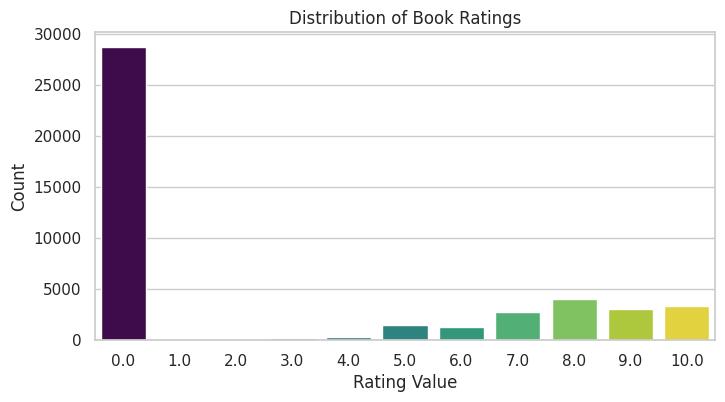

In [3]:
# Plot the distribution of ratings (hue and legend set to avoid FutureWarning)
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=df, hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating Value')
plt.ylabel('Count')
plt.show()

## Phase 2: Data Wrangling (User-Item Matrix)

We pivot the dataframe into a User-Item rating matrix, visualize the rating density (sparsity matrix heatmap), and apply mean-centering to normalize user ratings.

In [4]:
# Pivot the dataframe to create User-Item Matrix
user_item_matrix = df.pivot(index='user_id', columns='book_title', values='rating')

# Replace NaNs with 0 to represent unrated books
user_item_matrix_filled = user_item_matrix.fillna(0)

# Convert to float numpy array for matrix operations
R = user_item_matrix_filled.values.astype(float)

# Compute the mean rating for each user (based on filled matrix to avoid NaN issues during demeaning)
user_ratings_mean = np.mean(R, axis=1)

# Demean the rating matrix to normalize rating patterns and focus on relative preferences
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

print(f"Normalized User-Item Matrix shape: {R_demeaned.shape}")

Normalized User-Item Matrix shape: (2720, 1870)


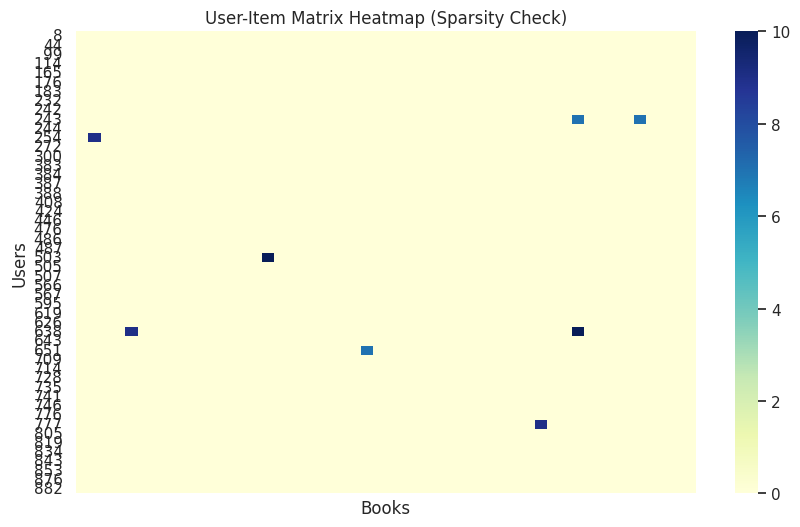

In [5]:
# Visualize matrix density using a heatmap (sparsity visualization)
plt.figure(figsize=(10, 6))
# Plotting a subset or full matrix depending on the size
sample_matrix = user_item_matrix_filled.iloc[:50, :50]
sns.heatmap(sample_matrix, cmap='YlGnBu', cbar=True, yticklabels=True, xticklabels=False)
plt.title('User-Item Matrix Heatmap (Sparsity Check)')
plt.xlabel('Books')
plt.ylabel('Users')
plt.show()

## Phase 3: Model Implementation (Matrix Factorization)

We decompose the User-Item matrix using SVD (`svds`), producing low-rank approximation matrices, and then reconstruct user predictions.

In [6]:
# Set number of latent factors (k)
k_factors = min(5, R_demeaned.shape[1] - 1) if df['user_id'].nunique() < 50 else 20

# Perform Singular Value Decomposition (SVD)
U, sigma, Vt = svds(R_demeaned, k=k_factors)
sigma = np.diag(sigma)

# Reconstruct the approximated Rating Matrix
predicted_ratings_demeaned = np.dot(np.dot(U, sigma), Vt)

# Add user means back to restore the original rating scale offset
predicted_ratings = predicted_ratings_demeaned + user_ratings_mean.reshape(-1, 1)

# Format predictions back into a DataFrame matching index and column schema
preds_df = pd.DataFrame(predicted_ratings, columns=user_item_matrix_filled.columns, index=user_item_matrix_filled.index)

print(f"U shape (Users x Latent Factors): {U.shape}")
print(f"Sigma shape (Latent Factors x Latent Factors): {sigma.shape}")
print(f"Vt shape (Latent Factors x Books): {Vt.shape}")
print(f"Reconstructed Ratings Matrix shape: {preds_df.shape}")

U shape (Users x Latent Factors): (2720, 20)
Sigma shape (Latent Factors x Latent Factors): (20, 20)
Vt shape (Latent Factors x Books): (20, 1870)
Reconstructed Ratings Matrix shape: (2720, 1870)


## Phase 4: Recommendation Output & Visualization

We write the helper function to query predictions, exclude books the target user has already rated, output the recommendations, and display them in a bar graph.


--- Top 5 Book Recommendations for User 8 ---
1. The Summons (Predicted Rating: 0.00)
2. Angels &amp; Demons (Predicted Rating: 0.00)
3. Harry Potter and the Sorcerer's Stone (Book 1) (Predicted Rating: 0.00)
4. A Prayer for Owen Meany (Predicted Rating: 0.00)
5. The Lovely Bones: A Novel (Predicted Rating: 0.00)


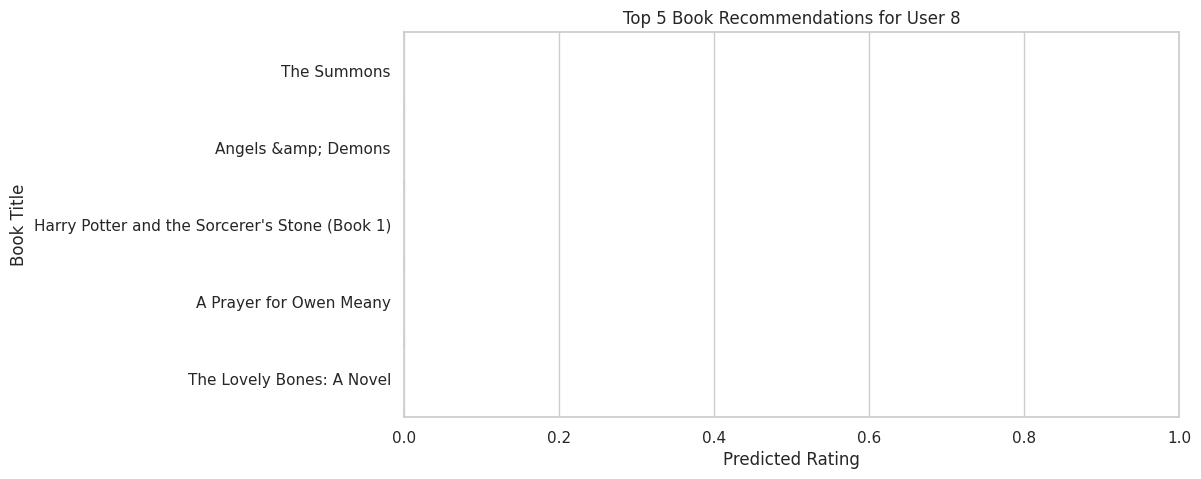

In [7]:
def get_book_recommendations(user_id, num_recommendations=5):
    """
    Recommends books for a given user based on reconstructed latent factor ratings
    and visualizes the predicted recommendation scores.
    """
    if user_id not in user_item_matrix.index:
        print(f"User {user_id} not found in the matrix.")
        return pd.Series(dtype=float)

    # 1. Fetch user's original ratings and identify books they have already rated
    user_ratings = user_item_matrix.loc[user_id]
    already_rated = user_ratings[user_ratings.notna()].index.tolist()

    # 2. Extract reconstructed rating predictions for the user
    user_predictions = preds_df.loc[user_id]

    # 3. Filter out rated books and return top recommendations sorted by predicted rating
    recommendations = user_predictions.drop(labels=already_rated)
    recommendations = recommendations.sort_values(ascending=False).head(num_recommendations)

    # Print the output in a clean, readable format
    print(f"\n--- Top {num_recommendations} Book Recommendations for User {user_id} ---")
    for rank, (book, score) in enumerate(recommendations.items(), 1):
        print(f"{rank}. {book} (Predicted Rating: {score:.2f})")

    # Visualize top recommendations using a bar chart (hue and legend set to avoid FutureWarning)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=recommendations.values, y=recommendations.index, hue=recommendations.index, palette='mako', legend=False)
    plt.title(f'Top {num_recommendations} Book Recommendations for User {user_id}')
    plt.xlabel('Predicted Rating')
    plt.ylabel('Book Title')
    plt.xlim(0, max(recommendations.values) + 1)
    plt.show()

    return recommendations

# Demonstrate recommendations on a sample user
sample_user_id = user_item_matrix.index[0]
get_book_recommendations(user_id=sample_user_id, num_recommendations=5);